# Анализ рынка компьютерных игр

Описание проекта.

**Заказчик**
Интернет-магазин «Стримчик», который продаёт по всему миру компьютерные игры.

**Интересы заказчика**

Выявить определяющие успешность игры закономерности, что позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

**Водные данные**

Исторические данные из открытых источников о продажах игр, оценки пользователей и экспертов, жанры и платформы. Данные датированы до 2016 года, данные за этот год могут быть неполными.

**Цель**

Прогнозирование рынка компьютерных игр на 2017 год.

**Задачи**
1. Выявить определяющие успешность игры закономерности.
2. Проверить несколько гипотез.
3. Написать рекомендации на 2017 год.


Описание данных
* Name — название игры
* Platform — платформа
* Year_of_Release — год выпуска
* Genre — жанр игры
* NA_sales — продажи в Северной Америке (миллионы проданных копий)
* EU_sales — продажи в Европе (миллионы проданных копий)
* JP_sales — продажи в Японии (миллионы проданных копий)
* Other_sales — продажи в других странах (миллионы проданных копий)
* Critic_Score — оценка критиков (максимум 100)
* User_Score — оценка пользователей (максимум 10)
* Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.
Данные за 2016 год могут быть неполными.

## Загрузка данных и знакомство с ними

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy import stats as st
from matplotlib.ticker import MultipleLocator

In [3]:
# Прочтем файл с данными
try:
    games = pd.read_csv('/datasets/games.csv')
except:
    games = pd.read_csv('games.csv')

In [4]:
# Выведем первые строки датафрейма
games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [5]:
# Выведем общую информацию о датафрейме
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [6]:
# Сохраним в переменную кол-во записей исходного датафрейма
shape = games.shape[0]

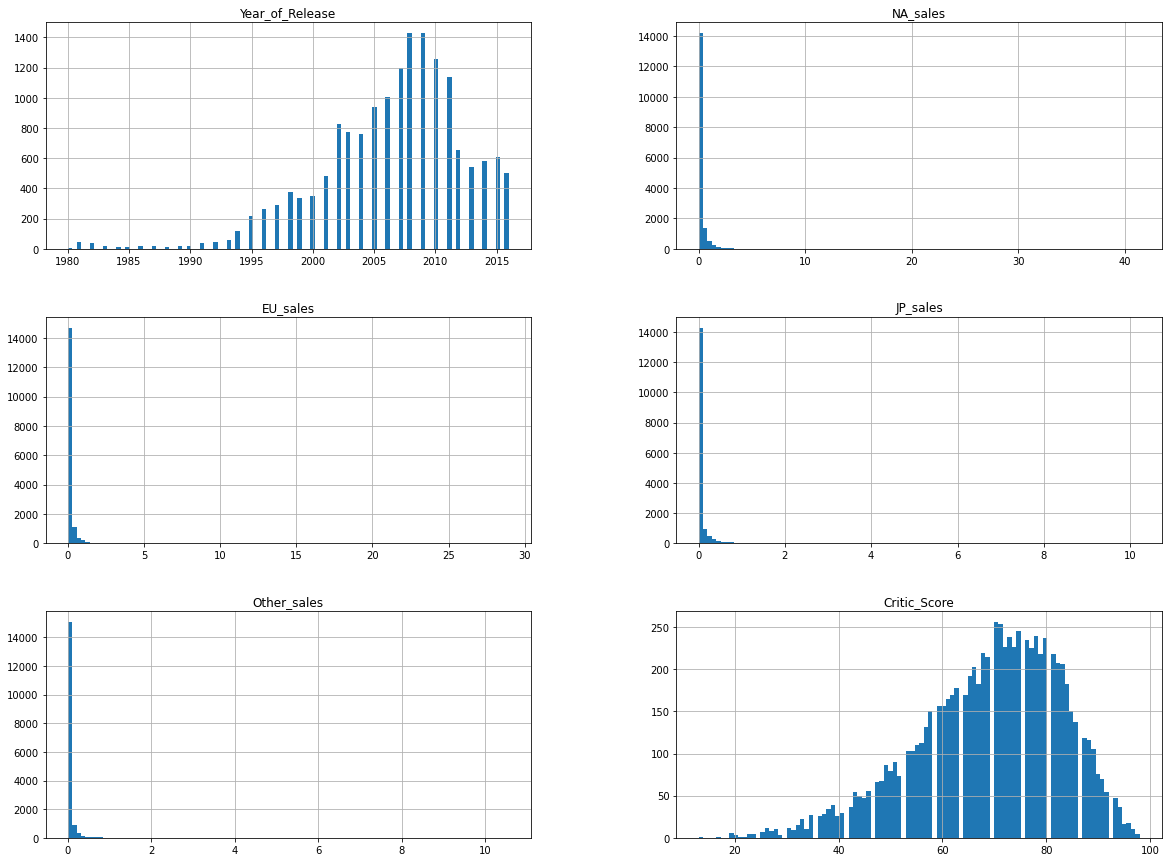

In [7]:
# Посмотрим гистограммы распределения числовых данных
games.hist(figsize=(20, 15), bins=100)
plt.show()

**ИТОГИ:**
1. В датафрейме 11 колонок и 16715 строк данных.
2. Стоит переименовать колонки (привести в нижний регистр).
3. Есть пропуски данных в некоторых колонках.
4. В колонках с кол-вом проданных копий игр большой разброс данных.
5. Нужно разобраться с данными и типом данных оценки пользователей.

## Предобработка данных

<font size="4"><b>2.1. Переименование колонок</b></font>

In [8]:
# Выведем названия колонок датафрейма
games.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')

In [9]:
# Переименуем колонки, приведем к нижнему регистру
games.columns = ['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales',
                'other_sales', 'critic_score', 'user_score', 'rating']

In [10]:
# Проверим результат
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

<font size="4"><b>2.2. Обработка пропусков данных</b></font>

In [11]:
# Функция для визуализации пропусков данных
def pass_value_barh(df):
    try:
        pass_part = (
            (df.isna().mean()*100) # находим долю пропусков
            .round(2)
            .to_frame()
            .rename(columns = {0:'part'})
            .query('part > 0') # если есть пропуски, то выводим
            .sort_values(by = 'part', ascending = True)
        )
        
#         Строим распределение столбиком 'лежа'
        pass_part.plot(kind = 'barh', figsize = (10,5), legend = False, fontsize = 14)
        
#         Выводим долю пропусков для каждого атрибута
        for index, value in enumerate(pass_part.part):
            plt.text(value, index, str(round(value, 1)), fontsize=12);
                       
        plt.title('Пропущенные значения\n', fontsize=18)
        plt.xlabel('\nКол-во пропусков, %', fontsize=14)
        plt.ylabel('Столбцы с пропусками\n', fontsize=14)
        plt.minorticks_on()
        plt.grid()
        plt.xlim(0, 100)    
    except:
        print('пропусков не осталось :) или произошла ошибка в первой части функции ')

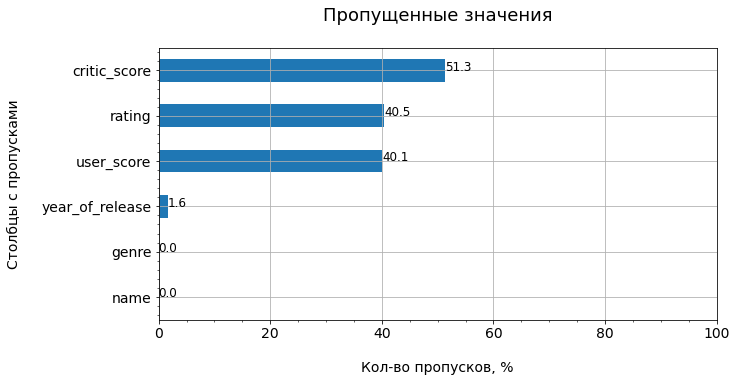

In [12]:
# Выведем график пропущенных значений для нашего датафрейма
pass_value_barh(games)

In [13]:
games[['name', 'genre', 'year_of_release']].isna().sum()

name                 2
genre                2
year_of_release    269
dtype: int64

1. Пройдемся по пропускам в названии и жанре игр.

In [14]:
# выведем строки с пропусками в названии игры
games[games.name.isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


Пропуски названия игры и жанра не удастся восстановить, к тому же, возможно, что строки являются неявными дубликатами. Просто удалим данные.

В этих же строках пропуски в жанре игр.

2. Год релиза игры тоже не восстановить, пропусков не так много. Сначала gосмотрим на данные без указания года релиза, нас интересуют продажи, выведем: минимальное, максимальное и сумму продаж по всем регионам.

In [15]:
# Среди игр без года релиза
games[games.year_of_release.isna()][['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].agg(['min', 'max','sum'])

,na_sales,eu_sales,jp_sales,other_sales
min,0.00,0.00,0.00,0.00
max,4.26,2.36,0.77,0.71
sum,59.15,24.46,6.70,8.61


In [16]:
# Среди всех данных
games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].agg(['min', 'max','sum'])

,na_sales,eu_sales,jp_sales,other_sales
min,0.00,0.00,0.00,0.00
max,41.36,28.96,10.22,10.57
sum,4402.35,2424.67,1297.37,791.32


Найдем какую долю от всех продаж составляют данные с пропусками.

In [17]:
f'{((59.15 + 24.46 + 6.70 + 8.61) / (4402.35 + 2424.67 + 1297.37 + 791.32)):.1%}'

'1.1%'

Итого, пропусков данных в годе релиза игры немного (1.6%), общая доля продаж по этим данным составляет 1.1% от общих продаж по всем данным. Исходя из этих фактов можно спокойно удалить строки с пропусками.

3. Удалим строки без названия игры, жанра и без года релиза игры

In [18]:
games.drop(
    games[(games.name.isna()) | (games.genre.isna()) | (games.year_of_release.isna())]
    .index, inplace=True
)

In [19]:
# Выведем долю потерь данных после удаления записей
print(f'Доля потерь данных: {((shape - games.shape[0]) / shape):.2%}')

Доля потерь данных: 1.62%


<font size="4"><b>2.3. Обработка типов данных</b></font> 

In [20]:
# Выведем общую информацию по датафрейму
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       9839 non-null   object 
 10  rating           9768 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.5+ MB


Проверим значения в колонках, точно ли они подходят по тип данных объект.

In [21]:
# Выведем уникальные значения оценки пользователей
games.user_score.unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [22]:
# Выведем уникальные жанры
games.genre.unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy'], dtype=object)

In [23]:
# Выведем игровые платформы
games.platform.unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne',
       'WiiU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [24]:
# Выведем ТОП-5 наиболее встречающихся оценок пользователей
games.user_score.value_counts().head()

tbd    2376
7.8     322
8       285
8.2     276
8.3     252
Name: user_score, dtype: int64

Разберемся со значением `tbd` a.k.a `to be determined`. Их доля составляет почти 25% от заполненных данных в колоке. Это может мешать анализу, так как сейчас тип данных для колонки стоит неверный.

Логичнее всего заменить значения на NaN, так как по факту пользователь не оценил игру, а замена на любое другое числовое значение может сказаться на результатах анализа.

In [25]:
# Заменим значения на np.nan
games.user_score.replace('tbd', np.nan, inplace=True)

In [26]:
# Выведем уникальные значения рейтинга игр
games.rating.unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

In [27]:
games.rating.value_counts()

E       3921
T       2905
M       1536
E10+    1393
EC         8
K-A        3
RP         1
AO         1
Name: rating, dtype: int64

В категориях рейтинга есть два названия одной категории: K-A, E. Объединим их в одну категорию (E). Для игр с пропусками жанра заполним пропуски категорией RP.

In [28]:
games.rating.replace('K-A', 'E', inplace=True)
games.rating.fillna('RP', inplace=True)

In [29]:
# Выведем уникальные значения рейтинга игр
games.rating.unique()

array(['E', 'RP', 'M', 'T', 'E10+', 'AO', 'EC'], dtype=object)

In [30]:
games.rating.value_counts()

RP      6677
E       3924
T       2905
M       1536
E10+    1393
EC         8
AO         1
Name: rating, dtype: int64

In [31]:
# Изменим тип данных некоторых колонок
#     user_score c object на float, так как оценка 1. числовая, 2. не целочисленная
games.user_score = games.user_score.astype('float')

#     year_of_release с float на int, так как логически это целочисленное значение
games.year_of_release = games.year_of_release.astype('int')


games.rating = games.rating.astype('category')


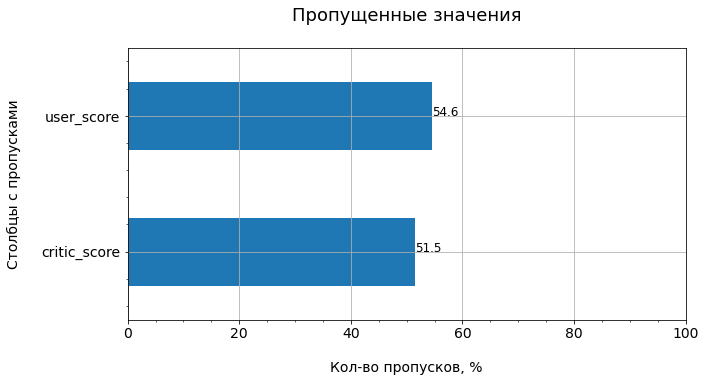

In [32]:
# Выведем график пропущенных значений для датафрейма,
# так как мы увеличили кол-во пропусков в колонке с оценками пользователей
pass_value_barh(games)

In [33]:
# Выведем общую информацию по датафрейму
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16444 non-null  object  
 1   platform         16444 non-null  object  
 2   year_of_release  16444 non-null  int64   
 3   genre            16444 non-null  object  
 4   na_sales         16444 non-null  float64 
 5   eu_sales         16444 non-null  float64 
 6   jp_sales         16444 non-null  float64 
 7   other_sales      16444 non-null  float64 
 8   critic_score     7983 non-null   float64 
 9   user_score       7463 non-null   float64 
 10  rating           16444 non-null  category
dtypes: category(1), float64(6), int64(1), object(3)
memory usage: 1.4+ MB


<font size="4"><b>2.4. Обработка дубликатов</b></font> 

In [34]:
# Ищем явные дубликаты
games.duplicated().sum()

0

In [35]:
# Ищем дубликаты по ключевым атрибутам
games[games.duplicated(['name', 'platform', 'year_of_release'], keep=False)].sort_values(by='name')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
604,Madden NFL 13,PS3,2012,Sports,2.11,0.22,0.0,0.23,83.0,5.5,E
16230,Madden NFL 13,PS3,2012,Sports,0.00,0.01,0.0,0.00,83.0,5.5,E


In [36]:
games.shape[0]

16444

In [37]:
# Удалим строку
games.drop(games[games.duplicated(['name', 'platform', 'year_of_release'])].index, inplace=True)

In [38]:
games.shape[0]

16443

<font size="4"><b>2.5. Добавление новых колонок</b></font>


Для продедения анализа понадобится колонка с суммарными продажами (по всем регионам), добавим ее.

In [39]:
# Добавим новый столбец, в котором посчитаем сумму продаж по всем регионам
games['total_sales'] = games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

In [40]:
# Выведем первые строки таблицы
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,RP,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,RP,31.38


In [41]:
# Проверим на наличие пропусков в новой колонке
games.total_sales.isna().sum()

0

**ИТОГИ:**
1. Названия колонок приведены к нижнему регистру.
2. Удалено 1.62% данных с пропусками к названии игры, названии жанра игры и годом релиза игры, так как данные нельзя восстановить,.
3. В данных с оценками пользователей и критиков имеется от 50% до 55% пропусков, которые нельзя устранить. Возможная причина пропусков - игра не оценена.
4. В данных с рейтингом игр имеется 40% пропусков, для анализа пропуски заполнены значением RP.
5. Изменен тип данных с оценками пользователей (float) и годом релиза игры (int).
6. Явные дубликаты не обнаружены, удален один неявный дубликат по ключевым параметрам: название игры, год релиза, платформа.
7. Добавлена колонка с суммарными продажами.

In [42]:
# check
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16443 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16443 non-null  object  
 1   platform         16443 non-null  object  
 2   year_of_release  16443 non-null  int64   
 3   genre            16443 non-null  object  
 4   na_sales         16443 non-null  float64 
 5   eu_sales         16443 non-null  float64 
 6   jp_sales         16443 non-null  float64 
 7   other_sales      16443 non-null  float64 
 8   critic_score     7982 non-null   float64 
 9   user_score       7462 non-null   float64 
 10  rating           16443 non-null  category
 11  total_sales      16443 non-null  float64 
dtypes: category(1), float64(7), int64(1), object(3)
memory usage: 1.5+ MB


## Исследовательский анализ данных

In [43]:
# Зададим параметры вывода графиков plt
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['font.size'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['hist.bins'] = 200
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['grid.linewidth'] = .3
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.linestyle'] = 'dashed'

In [44]:
# Функция, которая строит barh (кол-ко игр / записей)
def barh_count(df, y, title='title', ylabel='ylabel', sort='index'):
    if sort == 'index':
        barhs = games[y].value_counts().sort_index()
    elif sort == 'value':
         barhs = games[y].value_counts().sort_values()
    barhs.plot(kind='barh', figsize=(10, 10))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.minorticks_on()
    plt.xlabel('\nкол-во игр')
    plt.grid()    

    for index, value in enumerate(barhs):
        plt.text(value + 5, index, str(value), fontsize=12);
    return plt.show()

In [45]:
# Функция, которая строит barh (кол-ко игр / записей)
def bar_count(df, y, title='title', xlabel='xlabel', sort='index'):
    if sort == 'index':
        bars = games[y].value_counts().sort_index()
    elif sort == 'value':
         bars = games[y].value_counts().sort_values()
    bars.plot(kind='bar')
    plt.title(title)
    plt.xticks(rotation=0)
    plt.xlabel(xlabel)
    plt.locator_params(axis='x', nbins=8) 
    plt.ylabel('\nкол-во игр')
    plt.grid()    

#     for index, value in enumerate(bars):
#         plt.text(x=index, y=value, s=str(value), fontsize=12);
#     return plt.show()

In [46]:
# Функция, которая строит barh (кол-ко проданных копий)
def barh_agg(df, index, value, aggfunc='sum',  title='title', ylabel='ylabel',):
    barhs = df.pivot_table(index=index, values=value, aggfunc=aggfunc).sort_values(by=value)
    barhs.plot(kind='barh', figsize=(10, 10), legend=False)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.minorticks_on()
    plt.xlabel('\nпродажи, млн копий')
    plt.grid()    

    for ind, val in enumerate(barhs[value]):
        plt.text(val + 5, ind - 0.25, str(round(val)), fontsize=12);
    return plt.show()

### Годы выпуска игр

Посмотрим, сколько игр выпускалось в разные годы.

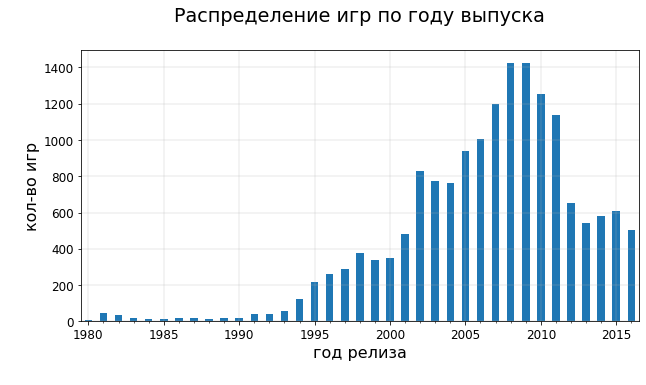

In [47]:
# Применим функцию, которая считает кол-во записей по фильтру
bar_count(games, y='year_of_release', title='Распределение игр по году выпуска\n', xlabel='год релиза\n', sort='index')


До 1995 года кол-во выпущенных игр в течение года достаточно мало. Но и для прогнозирования рынка такая фильтрация будет неправильной.

Для анализа данных нужно отфильтровать данные по актуальности. Для этого разберемся с продажами на разных платформах.

**ИТОГИ:**
1. Данные по играм представлены с 1980 года по 2016 год.
2. До 1995 года ежегодно выпускалось менее 100 игр.
2. Необходимо отфильтровать датафрейм по актуальности данных.

### Анализ продаж на разных платформах

Рассмотрим то, как менялись продажи игр по платформам. Для этого найдем платформы с наибольшими суммарными продажами.

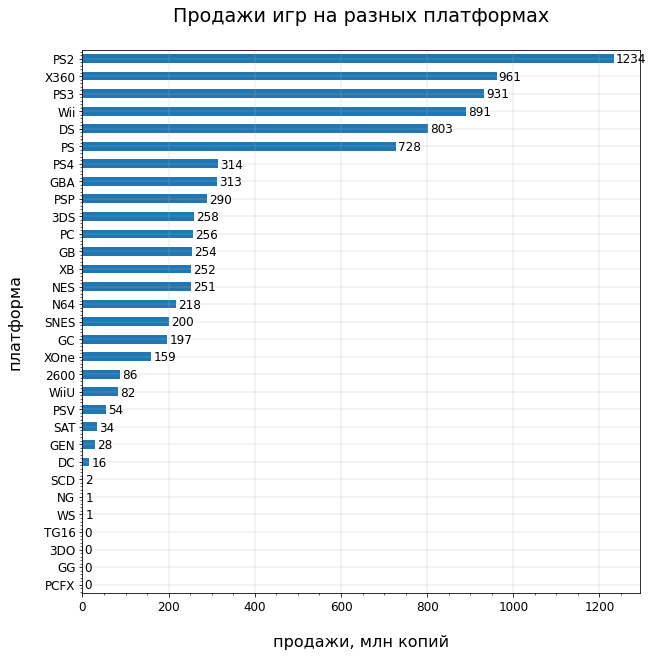

In [48]:
# Применим функцию, которая суммирует данные по фильтру
barh_agg(games,
         title='Продажи игр на разных платформах\n',
         ylabel='платформа\n',
         index='platform', value='total_sales', aggfunc='sum')

На графике наблюдаются 6 наиболее прибыльных платформ, с более 700 млн проданных копий разных игр. Построим для каждой из них график продаж по годам. 

#### ТОП-6 платформ (более 700 млн проданных копий)

In [49]:
# Построим сводную таблицу с информацие о кол-ве проданных копий на разных платформах
platforms_sales = games.pivot_table(index='platform', values='total_sales', aggfunc='sum')

# Названия платформ с более 700 млн копий проданных игр за все время
top_6_platforms = platforms_sales.query('total_sales > 700').index
display(top_6_platforms)

Index(['DS', 'PS', 'PS2', 'PS3', 'Wii', 'X360'], dtype='object', name='platform')

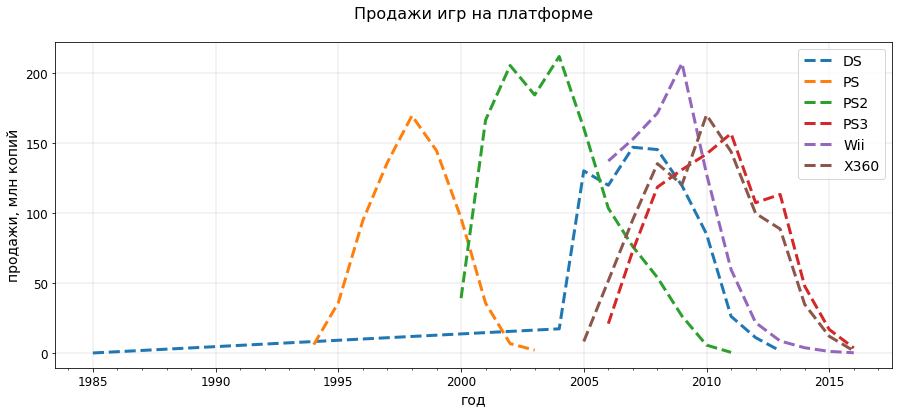

In [50]:
# Распределение кол-ва проданных копий игр по годам на платформах с более 700 млн копий игр за все время

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 6)) # создаем  subplots с сеткой размерности списка

# Платформы от самой прибыльной к мене прибыльной
for i, pl in enumerate(top_6_platforms): # для каждого элемента списка запоминаем номер элемента
    df = (games.query('platform == @pl')
         .pivot_table(index='year_of_release', values='total_sales', aggfunc='sum')
         )
    x = df.index
    y = df.total_sales
    ax.plot(x, y, label=pl)
    ax.legend(fontsize=14)
    ax.grid(True)
    ax.set_title(f'Продажи игр на платформе\n', fontsize=16)
    ax.set_ylabel('продажи, млн копий', fontsize=14)
    ax.set_xlabel('год', fontsize=14)

По графикам распределения можно сказать, что все 6 платформ с наибольшим кол-вом проданных копий игр, уже "отжили" или "доживают" свою популярность среди пользователей, так как кол-во продаж упало давно или наблюдается тенденция к снижению.

Посмотрим, сколько на данный момент (на конец 2016 года) просуществовали платформы.

In [51]:
# Посмотрим сколько 'живут' платформы

top_6_list = pd.DataFrame(columns=['nuniq', 'min_y', 'max_y'])
for pl in top_6_platforms: # для каждого элемента списка запоминаем номер элемента
#      Сколько лет на платформе выпускаются игры
    top_6_list.loc[pl,'nuniq'] = games.query('platform == @pl').year_of_release.nunique()
#     С какого года
    top_6_list.loc[pl,'min_y'] = games.query('platform == @pl').year_of_release.min()
#     По какой год
    top_6_list.loc[pl,'max_y'] = games.query('platform == @pl').year_of_release.max()
top_6_list.T

,DS,PS,PS2,PS3,Wii,X360
nuniq,11,10,12,11,11,12
min_y,1985,1994,2000,2006,2006,2005
max_y,2013,2003,2011,2016,2016,2016


In [52]:
# Найдем среднее время жизни игровой платформы
top_6_list.nuniq.mean().round()

11.0

Среди 6 самых "успешных" игровых платформ средняя время "жизни" платформы равно 11 годам.

#### ТОП-16 платформ (более 100 млн проданных копий)

На графике наблюдаются 16 наиболее прибыльных платформ, с более 100 млн проданных копий разных игр. Построим для каждой из них график продаж по годам. 

In [53]:
# Названия платформ с более 100 млн копий проданных игр за все время
top_16_platforms = platforms_sales.query('100 < total_sales').index
top_16_platforms

Index(['3DS', 'DS', 'GB', 'GBA', 'GC', 'N64', 'NES', 'PC', 'PS', 'PS2', 'PS3',
       'PS4', 'PSP', 'SNES', 'Wii', 'X360', 'XB', 'XOne'],
      dtype='object', name='platform')

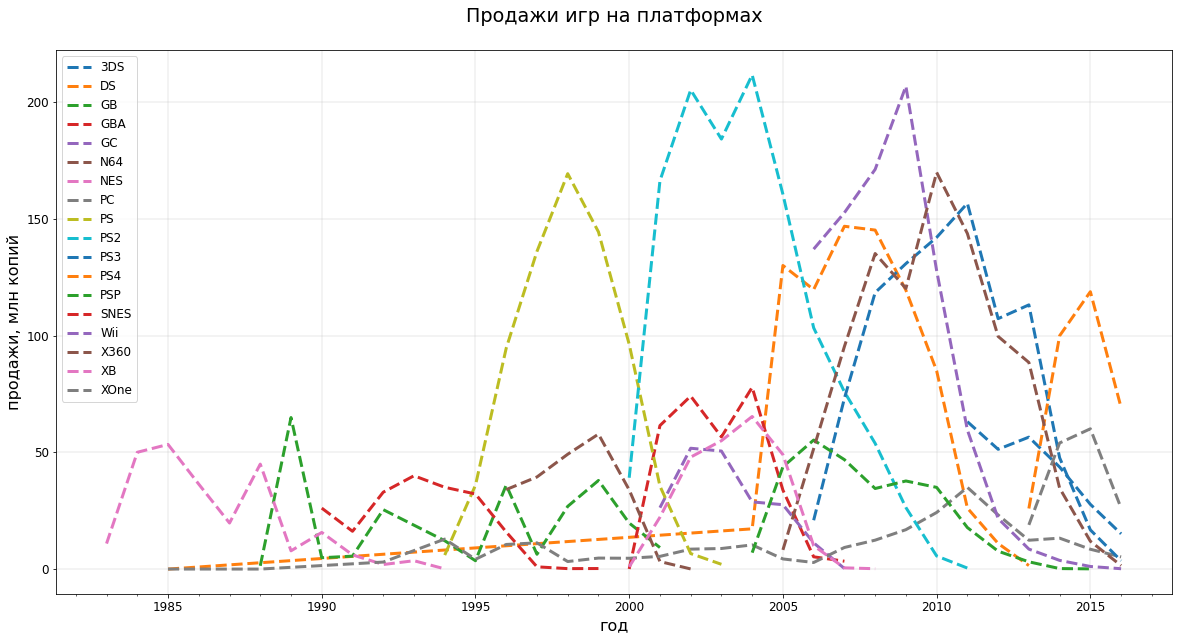

In [54]:
# Распределение кол-ва по годам на платформах с более 100 млн копий игр за все время

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))

for pl in top_16_platforms: 
    df = (games.query('platform == @pl')
         .pivot_table(index='year_of_release', values='total_sales', aggfunc='sum')
         )
    x = df.index
    y = df.total_sales
    ax.plot(x, y, label=pl)
    ax.legend(fontsize=12)
    ax.grid(True)
    ax.set_title(f'Продажи игр на платформах\n')
    ax.set_ylabel('продажи, млн копий')
    ax.set_xlabel('год')
plt.show()

По графикам распределения можно сказать, что все часть платформ с наибольшим кол-вом проданных копий игр, уже 'отжили' или 'доживают' свою популярность среди пользователей, другая часть относительно недавно появилась на рынке.

Продажи на ПК (PC) учитывать в цикле 'жизни' игровых платформ не будем. 

Посмотрим, сколько на данный момент (на конец 2016 года) просуществовали платформы.

In [55]:
# Посмотрим сколько живут платформы
top_16_list = pd.DataFrame(columns=['nuniq', 'min_y', 'max_y'])
for pl in top_16_platforms:
    if pl != 'PC':
        top_16_list.loc[pl,'nuniq'] = games.query('platform == @pl').year_of_release.nunique()
        top_16_list.loc[pl,'min_y'] = games.query('platform == @pl').year_of_release.min()
        top_16_list.loc[pl,'max_y'] = games.query('platform == @pl').year_of_release.max()
top_16_list.T

,3DS,DS,GB,GBA,GC,N64,NES,PS,PS2,PS3,PS4,PSP,SNES,Wii,X360,XB,XOne
nuniq,6,11,13,8,7,7,12,10,12,11,4,12,10,11,12,9,4
min_y,2011,1985,1988,2000,2001,1996,1983,1994,2000,2006,2013,2004,1990,2006,2005,2000,2013
max_y,2016,2013,2001,2007,2007,2002,1994,2003,2011,2016,2016,2015,1999,2016,2016,2008,2016


Среди платформ с более 100 млн проданных копий игр наблюдаются "новички" на рынке платформ, не будем их учитывать в оценке жизни платформ (6 и менее лет на рынке)

In [59]:
games.query('platform == "DS"').year_of_release.unique()

array([2006, 2005, 2010, 2009, 2004, 2007, 2012, 2008, 2011, 2013, 1985])

In [62]:
games.query('platform == "DS"').query('year_of_release ==1985')

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
15957,Strongest Tokyo University Shogi DS,DS,1985,Action,0.0,0.0,0.02,0.0,NaN,NaN,RP,0.02


In [60]:
# Найдем среднее время жизни игровой платформы
top_16_list.query('nuniq > 6').nuniq.mean().round()

10.0

#### Выбор актуальных данных для анализа

Для прогнозирования рынка на 2017 год нужно учесть цикл жизни платформ, а так же предусмотреть насколько актуальны данные за выбранный временной промежуток.

Для анализа подойдут данные начиная с 2014 года, так как это 2 полных отчетных периода, и неполный 2016 год, который не стоит отфильровывать.

In [61]:
# Отфильтруем данные
games_act = games.query('2013 < year_of_release')

**ИТОГИ:**
1. Выявлен жизненный цикл продаж игровых платформ: платформы существую на рынке в среднем 10 лет.
2. Для прогноза на 2017 год лучше рассматривать данные с 2014 года, так как за этот период можно рассмотреть более актуальные игровые тренды.

### Платформы-лидеры продаж

Найдем лидирующие поп родажам платформы.

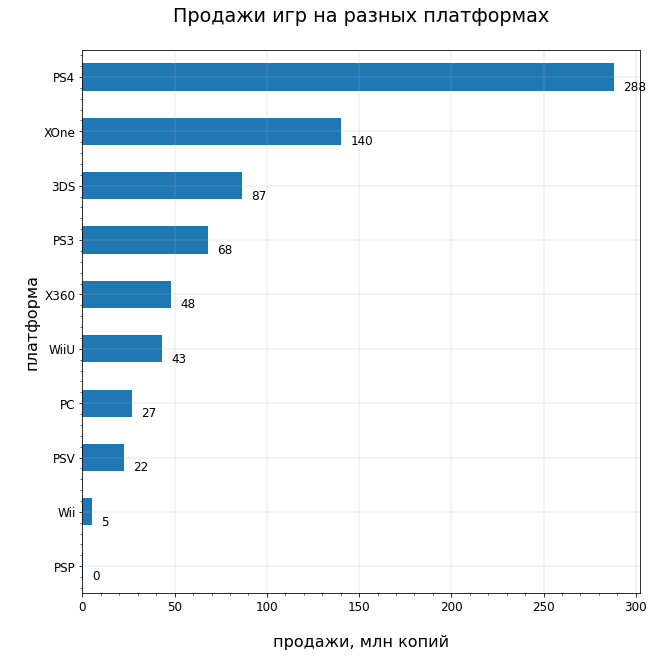

In [63]:
barh_agg(
    games_act,
    title='Продажи игр на разных платформах\n',
    ylabel='\nплатформа',
    index='platform', value='total_sales', aggfunc='sum'
)

Для каждой платформы построим график продаж по годам.

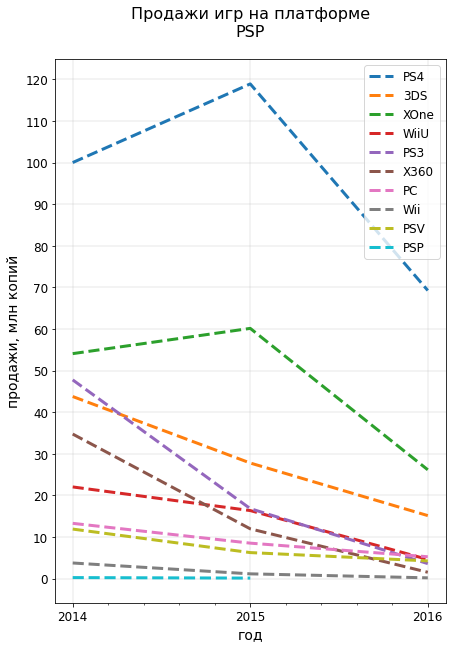

In [64]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7,10)) 

for pl in games_act.platform.unique():
    df = games_act.query('platform == @pl').pivot_table(
        index='year_of_release',
        values='total_sales',
        aggfunc='sum')
    x = df.index
    y = df.total_sales

    ax.plot(x, y, label=pl)

    ax.legend(fontsize=12)
    ax.grid(True)
    ax.set_title(f'Продажи игр на платформе\n{pl}\n', fontsize=16)
    ax.set_ylabel('продажи, млн копий', fontsize=14)
    ax.set_xlabel('год', fontsize=14)
    ax.yaxis.set_major_locator(MultipleLocator(base=10))
    ax.xaxis.set_major_locator(MultipleLocator(base=1))

plt.show()

Посмотрим на платформы, у которых продажи за 2015 год составили более 5 млн проданных копий.

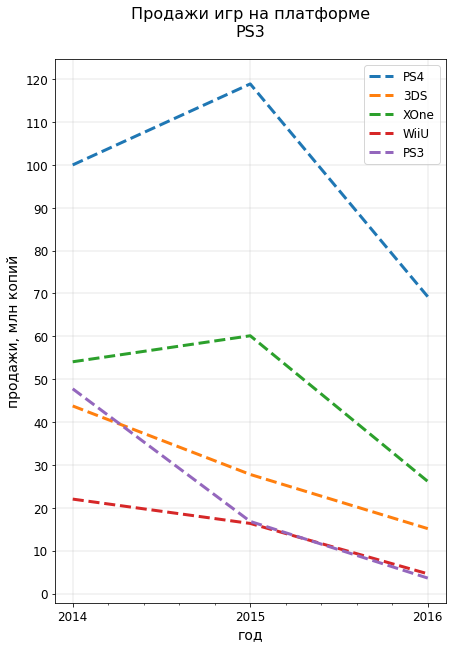

In [65]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7,10)) 

for pl in games_act.platform.unique():
    df = games_act.query('platform == @pl').pivot_table(
        index='year_of_release',
        values='total_sales',
        aggfunc='sum')
    x = df.index
    y = df.total_sales
    if df.loc[2015, 'total_sales'] > 15:
        ax.plot(x, y, label=pl)

        ax.legend(fontsize=12)
        ax.grid(True)
        ax.set_title(f'Продажи игр на платформе\n{pl}\n', fontsize=16)
        ax.set_ylabel('продажи, млн копий', fontsize=14)
        ax.set_xlabel('год', fontsize=14)
        ax.yaxis.set_major_locator(MultipleLocator(base=10))
        ax.xaxis.set_major_locator(MultipleLocator(base=1))

plt.show()

In [66]:
for el in ["PS4", "3DS", "XOne", "WiiU", "PC"]:
    print(el, games.query('platform == @el').year_of_release.nunique())


PS4 4
3DS 6
XOne 4
WiiU 5
PC 26


Наиболее прибыльными платформами кажутся PS4 и XOne, они не так давно на рынке, продажи идут на увеличение (если не учитывать данные за 2016 год). 

Так же платформ 3DS, WiiU, могут оказаться прибыльными, но они уже 5-6 лет на рынке и продажи идут на спад.

Не стоит исключать и релизы на ПК, так как он переживает все платформы.

**ИТОГИ:**
1. Наиболее прибыльные платформы с ростом продаж: PS4, XOne.
2. Наиболее прибыльные платформы со спадом продаж: 3DS, WiiU.
3. Прибыльная платформа, что дольше всех держится на рынке: PC.

### Наиболее прибыльные платформы

Рассмотрим суммарную прибыль платформ за актуальный период. Для этого построим график вида «ящик с усами».

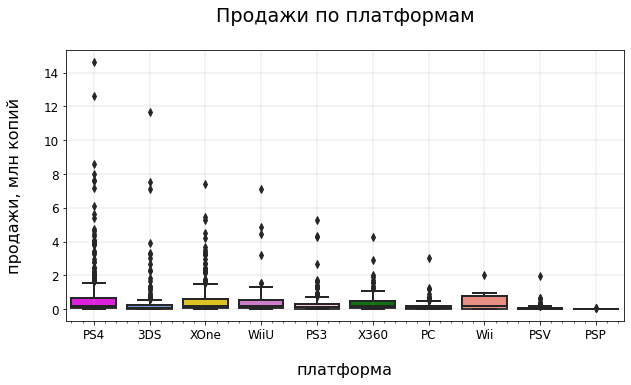

In [67]:
# В общем масштабе
sns.boxplot(x=games_act.platform, y=games_act.total_sales, linewidth=2,
           palette=['fuchsia', 'cornflowerblue', 'gold', 'orchid', 'pink', 'green', 'aquamarine', 'salmon', 'olive', 'chartreuse'])
plt.xlabel('\nплатформа')
plt.ylabel('продажи, млн копий\n')
plt.title('Продажи по платформам\n');
plt.suptitle('')
plt.grid()
plt.show()

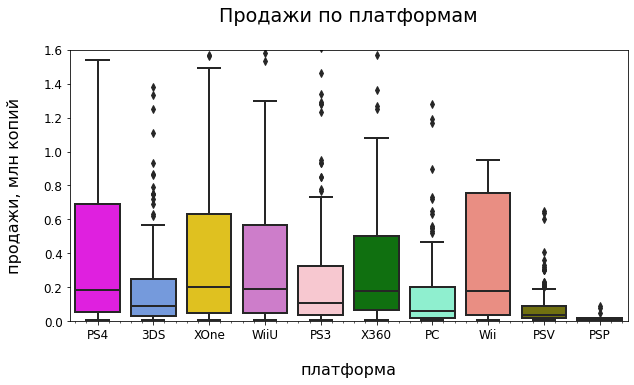

,platform,XOne,WiiU,PS4,Wii,X360,PS3,3DS,PC,PSV,PSP
median,total_sales,0.205,0.19,0.185,0.18,0.18,0.11,0.09,0.06,0.04,0.02


In [68]:
# В масштабе вкантилей
sns.boxplot(x=games_act.platform, y=games_act.total_sales, linewidth=2,
        palette=['fuchsia', 'cornflowerblue', 'gold', 'orchid', 'pink', 'green', 'aquamarine', 'salmon', 'olive', 'chartreuse'])
plt.ylim(0,1.6)
plt.xlabel('\nплатформа')
plt.ylabel('продажи, млн копий\n')
plt.title('Продажи по платформам\n');
plt.suptitle('')
plt.show()
(
    games_act.pivot_table(index='platform', values='total_sales', aggfunc=['median'])
    .sort_values(by=('median', 'total_sales'), ascending=False).T
)


**ИТОГИ:**
1. Платформы PS4, 3DS и XboxOne, WiiU являются наиболее "выстреливающими" по продажам платформами, то есть на этих платформах наибольший тирах проданных игр.
2. Если смотреть на среднестатистические продажи, то наибольший размах Q1-Q3 имеют платформы Wii, PS4, XOne, WiiU, X360.    
3. Наиболее прибильными платформами по медианным продажам являются: XOne, WiiU, PS4, Wii, X360.
4. Наименее прибыльные платформы: PSV, PSP

### Влияние отзывов на продажи

Посмотрим, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков.

In [69]:
games_act.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating',
       'total_sales'],
      dtype='object')

In [70]:
pop_platform_name = games_act.platform.value_counts().head(1).index[0]
pop_platform = games_act.query('platform == @pop_platform_name')
pop_platform_name

'PS4'

Проверим, что отзывов на платформе PS4 достаточо.

In [71]:
games_act.groupby('platform')['critic_score'].count().sort_values()

platform
PSP       0
Wii       0
X360     26
PS3      36
WiiU     43
3DS      51
PSV      54
PC      116
XOne    155
PS4     237
Name: critic_score, dtype: int64

In [72]:
games_act.loc[games_act['critic_score'].isna() & ['platform']=="PS4", 'critic_score'].count()

0

In [73]:
games_act.groupby('platform')['user_score'].count().sort_values()

platform
PSP       0
Wii       2
WiiU     48
3DS      55
PSV      73
X360     83
PS3      98
PC      122
XOne    165
PS4     242
Name: user_score, dtype: int64

In [74]:
games_act.loc[games_act['user_score'].isna() & ['platform']=="PS4", 'user_score'].count()

0

Пропусков данных в выборке по платформе нет.

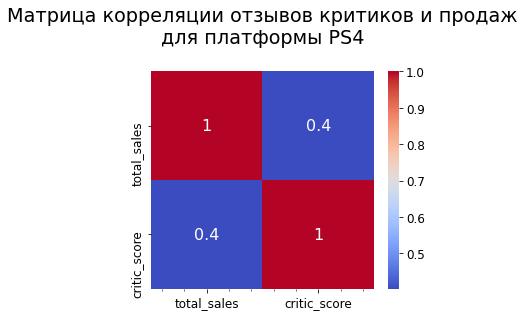

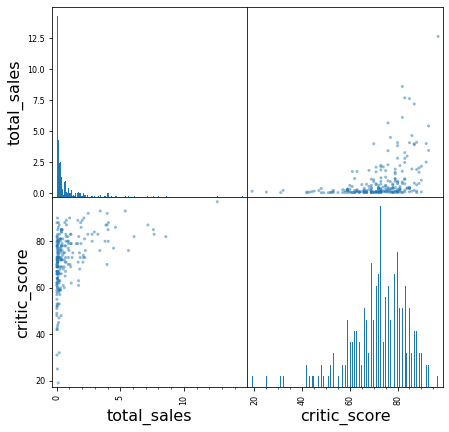

In [75]:
# Построим диаграмму рассеяния и посчитаем корреляцию между отзывами критиков и продажами.
df = pop_platform[['total_sales', 'critic_score']]

corr_m = df.corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_m, annot=True, cmap='coolwarm');
plt.title(f'Матрица корреляции отзывов критиков и продаж\nдля платформы {pop_platform_name}\n');

pd.plotting.scatter_matrix(df, figsize=(7, 7))
plt.show()

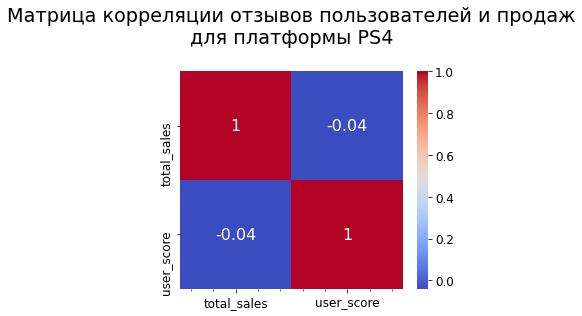

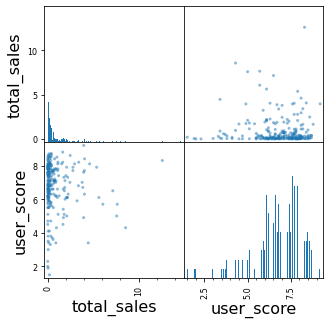

In [76]:
# Построим диаграмму рассеяния и посчитаем корреляцию между отзывами пользователей и продажами.
df = pop_platform[['total_sales', 'user_score']]

corr_m = df.corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_m, annot=True, cmap='coolwarm');
plt.title(f'Матрица корреляции отзывов пользователей и продаж\nдля платформы {pop_platform_name}\n');
pd.plotting.scatter_matrix(df, figsize=(5, 5))
plt.show()

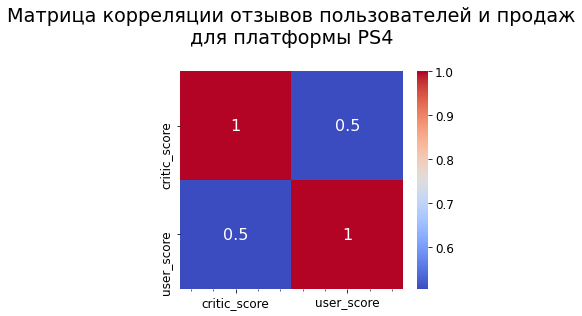

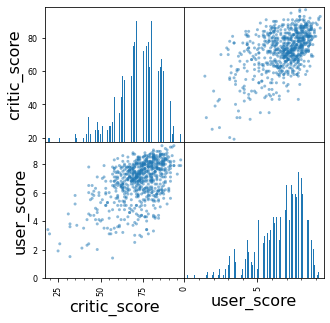

In [77]:
# Построим диаграмму рассеяния и посчитаем корреляцию между отзывами критиков и отзывами пользователей.
df = games_act[['critic_score', 'user_score']]

corr_m = df.corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_m, annot=True, cmap='coolwarm');
plt.title(f'Матрица корреляции отзывов пользователей и продаж\nдля платформы {pop_platform_name}\n');
pd.plotting.scatter_matrix(df, figsize=(5, 5))
plt.show()

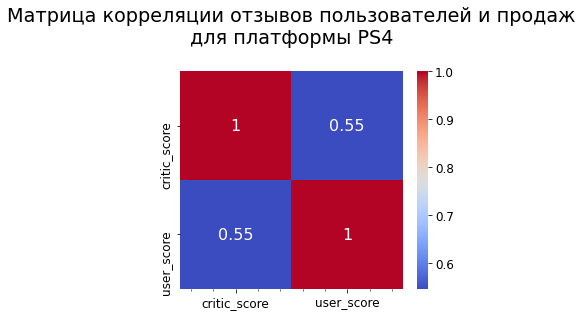

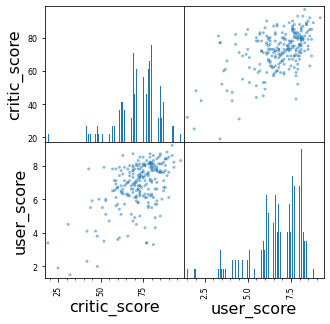

In [78]:
# Построим диаграмму рассеяния и посчитаем корреляцию между отзывами критиков и отзывами пользователей для всех платформ.
df = pop_platform[['critic_score', 'user_score']]

corr_m = df.corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_m, annot=True, cmap='coolwarm');
plt.title(f'Матрица корреляции отзывов пользователей и продаж\nдля платформы {pop_platform_name}\n');
pd.plotting.scatter_matrix(df, figsize=(5, 5))
plt.show()

**ИТОГИ:**
1. Оценки критиков игр на платформе PS4 могут влиять на общие продажи игр, тогда как внутри этой же платформы оценки пользователей почти не влияют на суммарные продажи.
2. Коэфф. кор. между отзывами критиков и пользователей для платформы PS4 и всех платформ близки. Вероятнее всего тенденция наблюдается зависимости от оценок критиков и независимости от оценок пользователей будет наблюдаться и на остальных платформах.

### Влияние жанра на продажи

Рассмотрим общее распределение игр по жанрам.

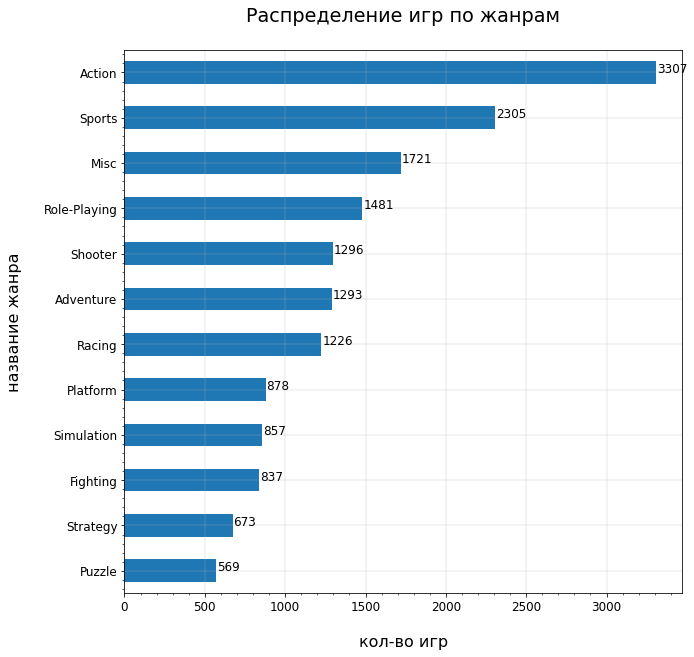

In [79]:
# Чтобы посмтореть распредление игр по жанрам применим функцию, считающую кол-во
barh_count(games_act,
           y='genre',
           title='Распределение игр по жанрам\n',
           ylabel='название жанра\n',
           sort='value')

На рынке чаще всего встречаются игры в жанрах action, sport, mics. Наименее часто встречающиеся жанры - strategy, puzzle.

Посмотрим прибыльность каждого жанра.

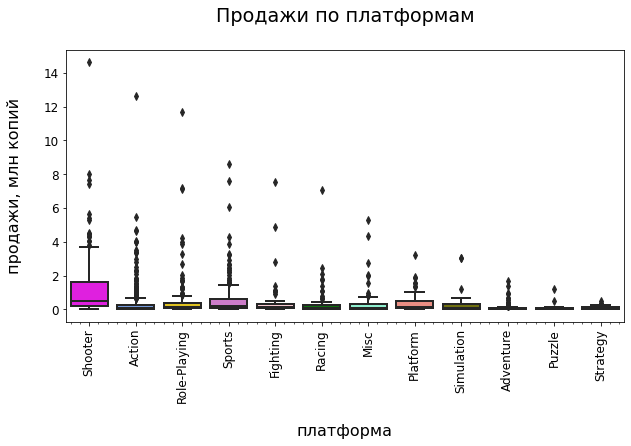

In [80]:
# В общем масштабе
sns.boxplot(x=games_act.genre, y=games_act.total_sales, linewidth=2,
           palette=['fuchsia', 'cornflowerblue', 'gold', 'orchid', 'pink', 'green', 'aquamarine', 'salmon', 'olive', 'chartreuse'])
plt.xlabel('\nплатформа')
plt.ylabel('продажи, млн копий\n')
plt.title('Продажи по платформам\n')
plt.xticks(rotation=90)
plt.suptitle('')
plt.show()

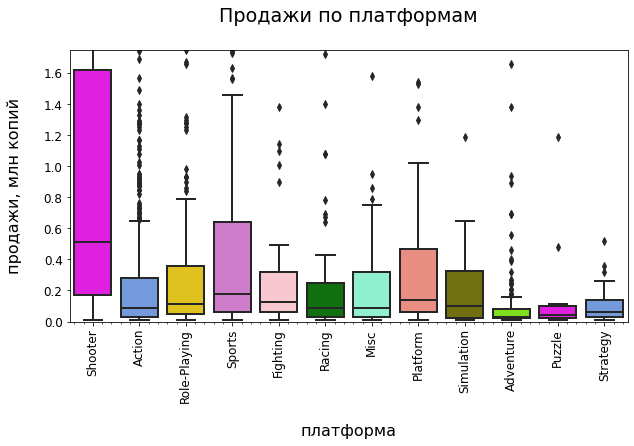

,genre,Shooter,Sports,Platform,Fighting,Role-Playing,Simulation,Action,Misc,Racing,Strategy,Puzzle,Adventure
median,total_sales,0.515,0.18,0.14,0.125,0.11,0.1,0.09,0.09,0.09,0.06,0.045,0.03


In [81]:
# В масштабе кантилей
sns.boxplot(x=games_act.genre, y=games_act.total_sales, linewidth=2,
        palette=['fuchsia', 'cornflowerblue', 'gold', 'orchid', 'pink', 'green', 'aquamarine', 'salmon', 'olive', 'chartreuse'])
plt.ylim(0,1.75)
plt.xlabel('\nплатформа')
plt.ylabel('продажи, млн копий\n')
plt.title('Продажи по платформам\n');
plt.suptitle('')
plt.xticks(rotation=90)
plt.show()
(
    games_act.pivot_table(index='genre', values='total_sales', aggfunc=['median'])
    .sort_values(by=('median', 'total_sales'), ascending=False).T
)

**ИТОГИ:**
1. Самый прибыльный жанр игр и по дисперсии общей прибыли, и по размаху продаж, и по медианным продажам (Q1-Q3) - shooter.
2. Следом по дисперсии прибыльности идут жанры - action, role-playing, sports.
3. По размаху (Q1-Q3) и медианным продажам прибыльными жанрами следом за шутерами можно назвать - sports, platform.
4. Наименее прибыльные платформы по обоим параметрам - puzzle, strategy.

## Портрет пользователя
Определим портрет пользователя для каждого региона (NA, EU, JP).


In [82]:
# Функция на входе получает датафрейм,
# название колонки, по которой группируем датафрейм,
# список названия колонок, значения которых должны быть включены в сводную таблицу (кол-во пирогов равно длине списка)
def pie_plotter_full(df, col, col_list, title): 
#     создаем сводную таблицу
    grouped = df.groupby(col)[col_list].agg('sum')
    
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,10))
    
    
    for i, el in enumerate(col_list):
        if grouped[el].shape[0] > 7: # если ел-тов много, то объениняем все в "другое"
            grouped.loc['Other', el] = grouped[el].sort_values(ascending=False).tail(len(grouped[el])-5).sum()
            labels = grouped[el].sort_values(ascending=False).head(6).index
            sizes = grouped[el].sort_values(ascending=False).head(6)
            
        else:
            labels = grouped[el].sort_values(ascending=False).index
            sizes = grouped[el].sort_values(ascending=False)
        dictionary = {
            'na': 'Северной Америке',
            'eu': 'Европе',
            'jp': 'Японии'
                     }
        ax[i].pie(sizes, labels=labels,
                  autopct='%1.0f%%',
                  textprops={'fontsize': 16},
                  colors=['tomato', 'cornflowerblue', 'gold', 'orchid', 'pink', 'green', 'aquamarine'],
                  pctdistance=.7, labeldistance=1.1)
        key=el.split("_")[0]
        ax[i].set_title(f'{title}\n в {dictionary.get(key)}\n')
        plt.subplots_adjust(wspace=0.3)
        
    return display(grouped.T)

### Самые популярные платформы (топ-5). 

Опишите различия в долях продаж.

platform,3DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne,Other
na_sales,22.64,7.23,22.05,98.61,0.00,2.52,2.08,19.36,28.30,81.27,31.19
eu_sales,16.12,17.97,25.54,130.04,0.00,3.53,2.59,13.15,15.49,46.25,34.76
jp_sales,44.24,0.00,11.22,15.02,0.36,14.54,0.00,7.31,0.08,0.32,0.76


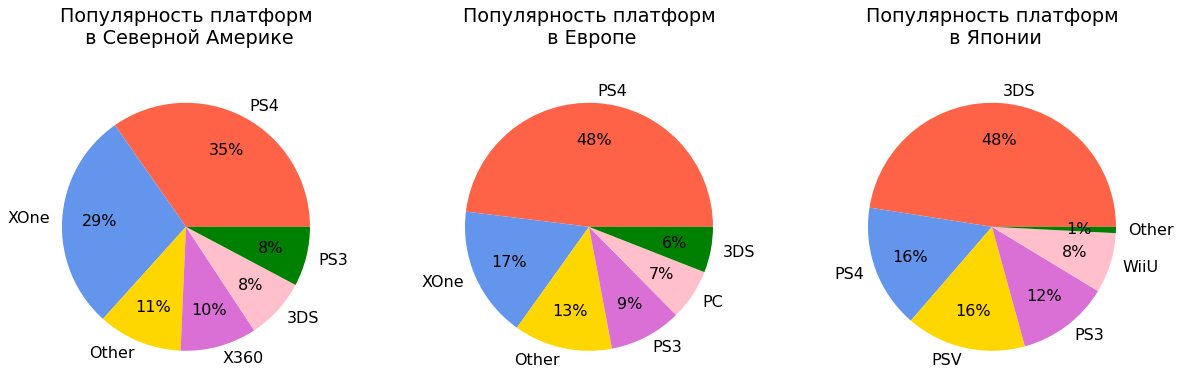

In [83]:
pie_plotter_full(games_act, col='platform', col_list=['na_sales', 'eu_sales', 'jp_sales'], title='Популярность платформ')

**ИТОГИ:**
1. ТОП-5 платформ Северной Америки: PS4->XOne->X360->3DS->PS3.
2. ТОП-5 платформ Европы: PS4->XOne->PS3->PC->3DS.
3. В ЕС и СА топ-5 платформ почти одинаковый, Различие в том, что в СА играют на X360, тогда как в ЕС предпочитают PC.
4. Тренды в японии отличаются от трендов Евр и СА.
2. ТОП-5 платформ Японии: 3DS->PS4->PSV->PS3->WiiU.


### Самые популярные жанры (топ-5).

Найдем самые популярные игровые жанры на рынках СА, ЕС, Японии.

genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy,Other
na_sales,72.53,5.64,12.43,15.05,6.79,0.65,8.74,33.47,79.02,2.63,46.13,0.98,37.86
eu_sales,74.68,6.49,6.69,12.86,6.80,0.52,14.13,28.17,65.52,7.30,45.73,1.79,42.45
jp_sales,29.58,3.60,6.37,5.61,2.69,0.93,1.76,31.16,4.87,2.31,3.26,0.95,15.50


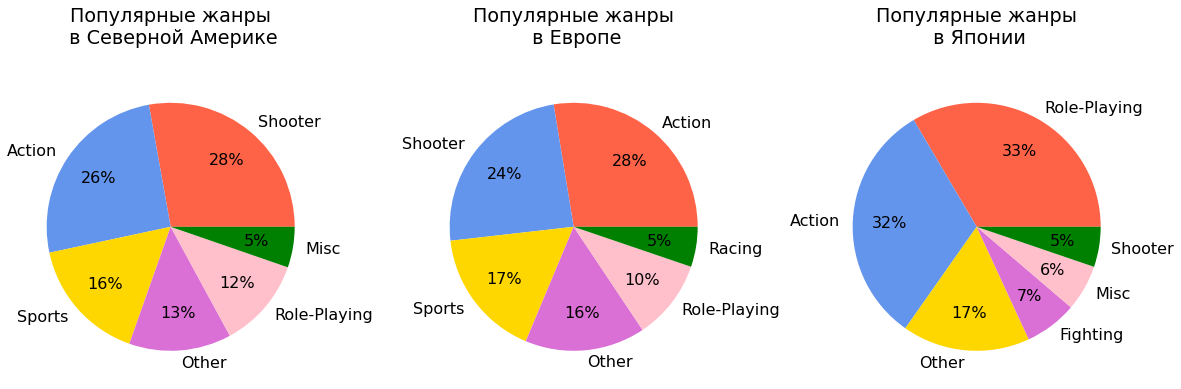

In [84]:
pie_plotter_full(games_act, col='genre', col_list=['na_sales', 'eu_sales', 'jp_sales'], title='Популярные жанры')

**ИТОГИ:**
1. ТОП-5 жанров игр Северной Америки: Shooter->Action->Sports->Role-Playing->Misc.
2. ТОП-5 жанров игр Европы: Action->Shooter->Sports->Role-Playing->Racing.
3. В ЕС и СА топ-5 жанров игр почти одинаковый. Различие в том, что в СА играют в Misc, тогда как в ЕС предпочитают играть в Racing.
4. Распределение трендов в Японии и здесь отличаются от распределения трендов в Евр и СА.
2. ТОП-5 жанров игр Японии: Role-Playing->Action->Fighting->Misc->Shooter.

### Рейтинг ESRB

Посмотрим, какие жанры игр предпочитают на разных рынках.

rating,AO,E,E10+,EC,M,RP,T
na_sales,0.0,50.74,33.23,0.0,96.42,64.72,38.95
eu_sales,0.0,58.06,26.16,0.0,93.44,58.95,34.07
jp_sales,0.0,8.94,4.46,0.0,8.01,56.90,14.78


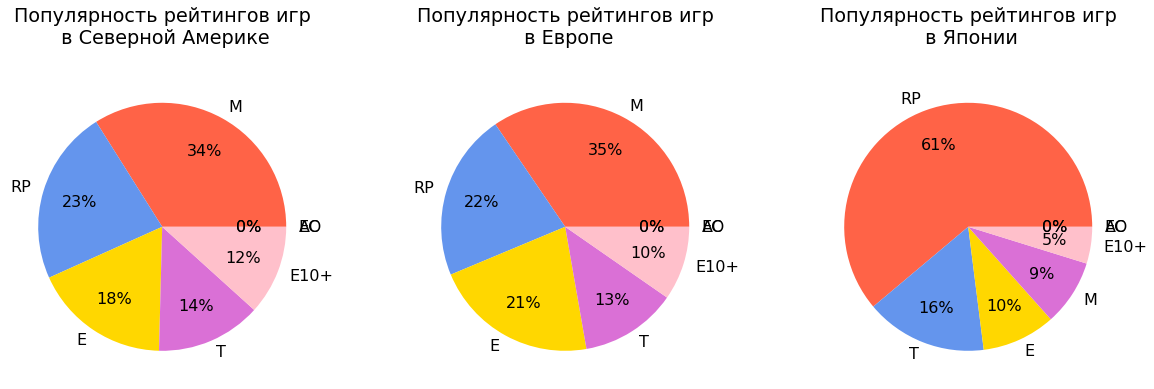

In [85]:
pie_plotter_full(games_act, col='rating', col_list=['na_sales', 'eu_sales', 'jp_sales'], title="Популярность рейтингов игр")

In [86]:
games_act.rating.value_counts()

RP      749
T       271
M       265
E       219
E10+    185
AO        0
EC        0
Name: rating, dtype: int64

**ИТОГИ:**
1. ТОП-5 рейтингов игр Северной Америки и Европы одинаковый: М(17+)->RP->E(6+)->T(13+)->E10+.
2. Распределение трендов в Японии и здесь отличаются от распределения трендов в Евр и СА.
3. ТОП-5 жанров игр Японии:  RP->T(13+)->E(6+)->М(17+)->E10+. Таким образом в Японии играют в игры, которые еще не получили рейтинг.

## Проверка гипотез

### Средние пользовательские рейтинги платформ Xbox One и PC одинаковые.

Проверим гипотезу:

Средние пользовательские рейтинги платформ Xbox One и PC одинаковые.

Альтернативная гипотеза:

Средние пользовательские рейтинги платформ Xbox One и PC не равны.

In [87]:
# Посмотрим сколько 'живут' платформы

top_6_list = pd.DataFrame(columns=['nuniq', 'min_y', 'max_y'])
for pl in ["XOne", 'PC']:
#      Сколько лет на платформе выпускаются игры
    top_6_list.loc[pl,'nuniq'] = games_act.query('platform == @pl').year_of_release.nunique()
#     С какого года
    top_6_list.loc[pl,'min_y'] = games_act.query('platform == @pl').year_of_release.min()
#     По какой год
    top_6_list.loc[pl,'max_y'] = games_act.query('platform == @pl').year_of_release.max()
top_6_list.T

,XOne,PC
nuniq,3,3
min_y,2014,2014
max_y,2016,2016


In [88]:
# H0 - Средние пользовательские рейтинги платформ Xbox One и PC равны
# H1 - Средние пользовательские рейтинги платформ Xbox One и PC не равны
h0 = games_act[games_act['user_score'].notna()].query('platform == "XOne"').user_score
h1 = games_act[games_act['user_score'].notna()].query('platform == "PC"').user_score
print(f'Среднее пользовательских рейтингов Xbox One: {np.mean(h0):.3}')
print(f'Среднее пользовательских рейтингов PC: {np.mean(h1):.3}')
print()

alpha = .05

results = st.ttest_ind(h0, h1, equal_var=False)
print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу. \
          \nСредние пользовательские рейтинги платформ Xbox One и PC не равны.')
else:
    print('Нет оснований отвергнуть нулевую гипотезу.\
          \nСредние пользовательские рейтинги платформ Xbox One и PC равны.')

Среднее пользовательских рейтингов Xbox One: 6.59
Среднее пользовательских рейтингов PC: 6.3

p-value: 0.11601398086668832
Нет оснований отвергнуть нулевую гипотезу.          
Средние пользовательские рейтинги платформ Xbox One и PC равны.


**ИТОГИ:**
1. Нет оснований отвергнуть нулевую гипотезу. Средние пользовательские рейтинги платформ Xbox One и PC равны.

In [89]:
# Приведены два датасета: сумма покупок, совершённых за месяц посетителями ...

sample_1 = [3071, 3636, 3454, 3151, 2185, 3259, 1727, 2263, 2015,
2582, 4815, 633, 3186, 887, 2028, 3589, 2564, 1422, 1785,
3180, 1770, 2716, 2546, 1848, 4644, 3134, 475, 2686,
1838, 3352]
sample_2 = [1211, 1228, 2157, 3699, 600, 1898, 1688, 1420, 5048, 3007,
509, 3777, 5583, 3949, 121, 1674, 4300, 1338, 3066,
3562, 1010, 2311, 462, 863, 2021, 528, 1849, 255,
1740, 2596]
alpha = .05 # критический уровень статистической значимости
# если p-value окажется меньше него - отвергнем гипотезу
results = st.ttest_ind(
sample_1,
sample_2)
print('p-значение:', results.pvalue)
if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

p-значение: 0.1912450522572209
Не получилось отвергнуть нулевую гипотезу


### Средние пользовательские рейтинги жанров Action и Sports разные.

Проверим гипотезу:

Средние пользовательские рейтинги жанров Action и Sports одинаковые.

Альтернативная гипотеза:

Средние пользовательские рейтинги жанров Action и Sports не равны.

In [90]:
# H0 - Средние пользовательские рейтинги жанров Action и Sports равны
# H1 - Средние пользовательские рейтинги жанра Action и Sports не равны
h0 = games_act[games_act['user_score'].notna()].query('genre == "Action"').user_score
h1 = games_act[games_act['user_score'].notna()].query('genre == "Sports"').user_score
print(f'Среднее пользовательских рейтингов жанра Action: {np.mean(h0):.3}')
print(f'Среднее пользовательских рейтингов жанра Sports: {np.mean(h1):.3}')
print()

alpha = .05

results = st.ttest_ind(h0, h1, equal_var=False)
print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу.\
          \nСредние пользовательские рейтинги жанра Action Sports не равны.')
else:
    print('Нет оснований отвергнуть нулевую гипотезу.\
          \nСредние пользовательские рейтинги жанров Action и Sports равны.')

Среднее пользовательских рейтингов жанра Action: 6.76
Среднее пользовательских рейтингов жанра Sports: 5.23

p-value: 1.1825550382644557e-14
Отвергаем нулевую гипотезу.          
Средние пользовательские рейтинги жанра Action Sports не равны.


Нулевая гипотеза опровергнута, проверим следующую связку гипотез.

Проверим гипотезу:

Средние пользовательские рейтинги жанров Action и Sports одинаковые.

Альтернативная гипотеза:

Средние пользовательские рейтинги жанра Action больше, чем жанра Sports.

In [91]:
# H0 - Средние пользовательские рейтинги жанров Action и Sports равны
# H1 - Средние пользовательские рейтинги жанра Action больше, чем жанра Sports
h0 = games_act[games_act['user_score'].notna()].query('genre == "Action"').user_score
h1 = games_act[games_act['user_score'].notna()].query('genre == "Sports"').user_score
print(f'Среднее пользовательских рейтингов жанра Action: {np.mean(h0):.3}')
print(f'Среднее пользовательских рейтингов жанра Sports: {np.mean(h1):.3}')
print()

alpha = .05

results = st.ttest_ind(h0, h1, equal_var=False, alternative='greater')
print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу.\
          \nСредние пользовательские рейтинги жанра Action больше, чем жанра Sports.')
else:
    print('Нет оснований отвергнуть нулевую гипотезу.\
          \nСредние пользовательские рейтинги жанров Action и Sports равны.')

Среднее пользовательских рейтингов жанра Action: 6.76
Среднее пользовательских рейтингов жанра Sports: 5.23

p-value: 5.912775191322278e-15
Отвергаем нулевую гипотезу.          
Средние пользовательские рейтинги жанра Action больше, чем жанра Sports.


**ИТОГИ:**
1. Нулевая гипотеза опровергнута. Средние пользовательские рейтинги жанра Action больше, чем жанра Sports.

## Итоги исследования

Были получены исторические данные из открытых источников: о продажах игр, оценки пользователей и экспертов, жанры и платформы. Данные датированы до 2016 года, данные за этот год могут быть неполными.

**Цель**

Прогнозирование рынка компьюреных игр на 2017 год.

**Задачи**
1. Выявить определяющие успешность игры закономерности.
2. Проверить несколько гипотез.
3. Написать рекомендации на 2017 год.

**1. Знакомство с данными**

В ходе изучения исходного датафрейма выявлено следующее:
1. В датафрейме 11 колонок и 16715 строк данных.
3. Есть пропуски данных в некоторых колонках.
4. В колонках с кол-вом проданных копий игр большой разброс данных.

**2. Предобработка данных**

В ходе подготовки данных к анализу проделаны следующие работы:
1. Удалены данные с пропусками в названии игры, названии жанра игры и годом релиза игры, так как данные нельзя восстановить. Возможная причина пропусков - игра не оценена.
2. В данных с оценками пользователей и критиков имеется от 50% до 55% пропусков, которые нельзя устранить. Заменены значения оценки пользователе **tbd** на пропуски.
3. В данных с рейтингом игр имеется 40% пропусков, для анализа пропуски заполнены значением **RP**.
4. Явные дубликаты не обнаружены, удален один неявный дубликат по ключевым параметрам: название игры, год релиза, платформа.
5. Добавлена колонка с суммарными продажами.

**3. Исследовательский анализ данных**

В ходе исследования данных выялено следующее:

***Год выпуска игры***
1. Выявлен жизненный цикл продаж игровых платформ: в среднем 10 лет на рынке.
2. Для прогноза на 2017 год рассматривались данные с 2014 года, чтобы учесть более актуальные игровые тренды.

***Платформы лидеры продаж***
1. Наиболее прибыльные платформы с ростом продаж на 2014-2016 годы: PS4, XOne.
2. Наиболее прибыльные платформы со спадом продаж на 2014-2016 годы: 3DS, WiiU.
3. Прибыльная платформа, что дольше всех держится на рынке: PC.

1. Платформы PS4, 3DS и XboxOne, WiiU являются наиболее "выстреливающими" по продажам, то есть на этих платформах больше всего продано копий игр.
2. Наибольший среднестатистический размаж продаж (Q1-Q3) имеют платформы: Wii, PS4, XOne, WiiU, X360.    
3. Наиболее прибильными платформами по медианным продажам являются: XOne, WiiU, PS4, Wii, X360.
4. Наименее прибыльные платформы: PSV, PSP

***Влияние отзывов на продажи***
1. Оценки критиков игр на платформе PS4 могут влиять на общие продажи игр, тогда как внутри этой же платформы оценки пользователей почти не влияют на суммарные продажи.
2. Коэфф. кор. между отзывами критиков и пользователей для платформы PS4 и всех платформ близки. Вероятнее всего тенденция наблюдается зависимости от оценок критиков и независимости от оценок пользователей будет наблюдаться и на остальных платформах.

***Влияние жанра игры на продажи***
1. Самый прибыльный жанр игр и по дисперсии общей прибыли, и по размаху (Q1-Q3) - shooter.
2. Следом по дисперсии прибыльности идут жанры - action, role-playing, sports.
3. По размаху (Q1-Q3) прибыльными жанрами можно назвать - sports, platform.
4. Наименее прибыльные платформы по обоим параметрам - puzzle, strategy.

**4. Портреты пользователей**

В ходе изучения предпочтений пользователей платформ на разных игровых рынках (Северная Америка, Европы, Японии) выявлены следующие факты:

***Популярные игровые платформы***
1. В ЕС и СА топ-5 платформ почти одинаковый. Различие в том, что в СА играют на X360, тогда как в ЕС предпочитают PC.
2. Тренды в Японии отличаются от трендов ЕС и СА.

| № | Сев.Америка | Европа | Япония |
|:-:|:-----------:|:------:|:------:|
|1|PS4|PS4|3DS|
|2|XOne|XOne|PS4
|3|X360|PS3|PSV|
|4|3DS|PC|PS3|
|5|PS3|3DS|WiiU|



***Популярные жанры игр***
1. В ЕС и СА топ-5 жанров игр почти одинаковый. Различие в том, что в СА играют в Misc, тогда как в ЕС предпочитают играть в Racing.
2. Распределение трендов в Японии и здесь отличаются от распределения трендов в ЕС и СА.

| № | Сев.Америка | Европа | Япония |
|:-:|:-----------:|:------:|:------:|
|1|Shooter|Action|Playing|
|2|Action|Sports|Action|
|3|Sports|Role-Playing|Fighting|
|4|Role-Playing|Role-Playing|Misc|
|5|Misc|Racing|Shooter|

**Популярные рейтинги игр**
1. ТОП-5 рейтингов игр Северной Америки и Евросоюза одинаковый.
2. Распределение трендов в Японии и здесь отличаются от распределения трендов в ЕС и СА.
3. ТОП-5 жанров игр Японии:  RP->T(13+)->E(6+)->М(17+)->E10+. Таким образом в Японии играют в игры, которые еще не получили рейтинг.
| № | Сев.Америка и Европа | Япония |
|:-:|:--------------------:|:--------:|
|1|M|RP|
|2|RP|T|
|3|E|E|
|4|T|M|
|5|E10+|E10+|

**5. Проверка гипотез**

1. В ходе проверки гипотезы о том, что `Средние пользовательские рейтинги платформ Xbox One и PC равны` с альтернативной гипотезой, что `Средние пользовательские рейтинги платформ Xbox One и PC не равны`, выявлено, что нет оснований отвергнуть нулевую гипотезу. 

Таким образом, **средние пользовательские рейтинги платформ Xbox One и PC равны**.

2. В ходе проверки гипотезы о том, что `Средние пользовательские рейтинги жанров Action и Sports равны` с альтернативной гипотезой, что `Средние пользовательские рейтинги жанров Action и Sports не равны` нулевая гипотеза была опровергнута. 

3. Была проверена другая связка гипотез: нулевая гипотеза `Средние пользовательские рейтинги жанров Action и Sports равны` с альтернативной гипотезой, что `Средние пользовательские рейтинги жанров Action больше, чем жарна Sports не равны`. В ходе проверки нулевая гипотеза была опровергнута в пользу альтернативной.

Таким образом, **средние пользовательские рейтинги жанра Action больше, чем средние пользовательские рейтинги  жанра Sports**.

**6. Рекомендации**

**Рекомендации**
1. Для рынка в Северной америке стоит обратить внимание на игры жанра Shooter на платформе PlayStation4. Рейтинг M(17+).
2. Для рынка в Европе стоит обратить внимание на игры жанра Action на платформе PlayStation4. Рейтинг M(17+).
3. Для рынка в Японии стоит обратить внимание на игры жанра Playing на платформе Nintendo 3DS. 

** Общие анти-рекомендации**
1. Игры для платформ PSV, PSP.
2. Жанры игр puzzle, strategy.